# Multi-Head Attention: From Scratch (NumPy) vs. Scikit-Learn for Sentiment Analysis

This notebook provides a hands-on exploration of **Multi-Head Attention** — the core mechanism behind Transformer models — from a full NumPy from-scratch implementation to sklearn baselines. We apply it to **binary sentiment classification** on movie reviews.

## Prerequisites
- Scaled dot-product attention basics (Q, K, V)
- Softmax and matrix multiplication
- Basic text preprocessing (tokenization, padding)
- sklearn `LogisticRegression` familiarity

## Dataset
[IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Credits:** This dataset contains 50,000 movie reviews from IMDB, labeled as positive (1) or negative (0) sentiment. Originally collected by Maas et al. for ACL 2011.

In [1]:
import numpy as np              # Numerical operations and array computations
import pandas as pd             # Data loading, manipulation, and analysis
import matplotlib.pyplot as plt # Plotting and visualizations
import seaborn as sns           # Enhanced statistical visualizations
import re                       # Regular expressions for text cleaning
from collections import Counter # Building vocabulary from tokenized text
import warnings                 # Suppress irrelevant warnings
import time                     # Benchmarking execution time
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF features for sklearn baseline
from sklearn.linear_model import LogisticRegression          # Strong text classification baseline
from sklearn.model_selection import train_test_split         # Stratified train/test splitting
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

np.random.seed(42)  # Reproducibility across all random operations

## Part 1: Theory Recap — Multi-Head Attention

- **Scaled Dot-Product Attention:** Given Query (Q), Key (K), and Value (V) matrices, compute attention as `softmax(Q @ K^T / sqrt(d_k)) @ V`. The scaling factor `sqrt(d_k)` prevents the dot products from growing too large, keeping gradients stable.
- **Multi-Head Attention:** Instead of one attention function, project Q, K, V into `h` lower-dimensional subspaces (`d_k = d_model / h`), apply attention in each head independently, concatenate the outputs, and project back to `d_model`. Each head learns to attend to different relationships.
- **Parameter Matrices:** Four weight matrices per MHA layer: `W_Q`, `W_K`, `W_V` (input projections), and `W_O` (output projection). Total parameters = `4 * d_model^2`.
- **Why Multiple Heads?** Single-head attention averages information across positions; multiple heads allow the model to jointly attend to information from different representation subspaces at different positions (e.g., syntax in one head, semantics in another).
- **Masking:** In self-attention, padding tokens are masked by setting their attention scores to `-inf` before softmax, ensuring they contribute zero weight to the output.

### Load the Real-World Dataset

We load the IMDB movie review dataset (50K reviews), inspect its structure, and understand the feature-target relationship. The task is binary sentiment classification: predict whether a review is positive (1) or negative (0).

In [2]:
import kagglehub

# Download IMDB dataset from Kaggle
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(f"{path}/IMDB Dataset.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset info:")
df.info()
print("\nStatistical summary:")
display(df.describe())

# Check class balance
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

# Encode target: positive -> 1, negative -> 0
df['label'] = (df['sentiment'] == 'positive').astype(int)

# Features: review text (strings)
# Target: label (0 or 1)
print("\nFeatures: review column (text)")
print("Target: label column (0=negative, 1=positive)")

100%|██████████| 25.7M/25.7M [00:00<00:00, 117MB/s]

Extracting files...


Dataset shape: (50000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Statistical summary:


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000



Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Features: review column (text)
Target: label column (0=negative, 1=positive)


In [3]:
# --- Text Cleaning ---
def clean_text(text):
    """Lowercase, remove HTML tags, non-alphabetic chars, extra spaces."""
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)       # Remove <br> tags
    text = re.sub(r'[^a-z\s]', '', text)          # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()      # Collapse multiple spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)

# --- Subset for faster training (3000 samples, stratified) ---
positive = df[df['label'] == 1].sample(n=1000, random_state=42)
negative = df[df['label'] == 0].sample(n=1000, random_state=42)
df_sub = pd.concat([positive, negative]).sample(frac=1, random_state=42).reset_index(drop=True)

# --- Build vocabulary from training split only (to avoid data leakage) ---
reviews_train, reviews_test, y_train, y_test = train_test_split(
    df_sub['clean_review'], df_sub['label'], test_size=0.2, random_state=42, stratify=df_sub['label']
)

def tokenize(text):
    return text.split()

VOCAB_SIZE = 3000  # Keep most frequent words
MAX_LEN = 60      # Truncate / pad to this length

# Build vocabulary from training tokens
word_counts = Counter()
for rev in reviews_train:
    word_counts.update(tokenize(rev))

# Map word -> index (reserve 0 for padding, 1 for OOV)
vocab = {word: idx + 2 for idx, (word, _) in enumerate(word_counts.most_common(VOCAB_SIZE - 2))}
vocab['<PAD>'] = 0
vocab['<OOV>'] = 1
idx_to_word = {v: k for k, v in vocab.items()}

def encode(text, vocab, max_len):
    """Convert text to padded sequence of word indices."""
    tokens = tokenize(text)[:max_len]
    indices = [vocab.get(t, vocab['<OOV>']) for t in tokens]
    # Pad with <PAD> (0) to max_len
    indices = indices + [0] * (max_len - len(indices))
    return np.array(indices, dtype=np.int32)

X_train = np.array([encode(rev, vocab, MAX_LEN) for rev in reviews_train])
X_test = np.array([encode(rev, vocab, MAX_LEN) for rev in reviews_test])
y_train = y_train.values
y_test = y_test.values

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Vocabulary size: {len(vocab)}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Padding token ID: {vocab['<PAD>']}, OOV token ID: {vocab['<OOV>']}")

Training samples: 1600, Test samples: 400
Vocabulary size: 3000
Max sequence length: 60
Padding token ID: 0, OOV token ID: 1


## Part 2: From Scratch Implementation (NumPy Only)

We implement the full Multi-Head Attention mechanism — scaled dot-product attention, multi-head splitting, and end-to-end classification — using **only NumPy**. We also implement backpropagation through all layers to train the model. This gives us a deep understanding of every gradient that flows through a Transformer's attention block.

In [4]:
# ============================================================
# SCALED DOT-PRODUCT ATTENTION (Core building block)
# ============================================================
class ScaledDotProductAttention:
    """
    Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V

    Operates on batched multi-head tensors:
      Q, K, V shape: (batch_size, num_heads, seq_len, d_k)
    """
    def __init__(self):
        self.cache = {}  # Store intermediates for backward

    def _softmax(self, x, axis=-1):
        """Numerically stable softmax."""
        x_max = np.max(x, axis=axis, keepdims=True)
        exp_x = np.exp(x - x_max)
        return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

    def forward(self, Q, K, V, mask=None):
        """
        Forward pass for scaled dot-product attention.

        Args:
            Q, K, V: (batch, heads, seq_len, d_k)
            mask: (batch, 1, 1, seq_len) or None; True = positions to mask
        Returns:
            output: (batch, heads, seq_len, d_k)
            attention_weights: (batch, heads, seq_len, seq_len)
        """
        d_k = Q.shape[-1]
        # scores: (batch, heads, seq_len_q, seq_len_k)
        scores = np.matmul(Q, K.transpose(0, 1, 3, 2)) / np.sqrt(d_k)
        # INTERVIEW NOTE: sqrt(d_k) scaling prevents dot products from growing large
        # as d_k increases, which would push softmax into regions with vanishing gradients.
        if mask is not None:
            scores = np.where(mask, -1e9, scores)  # Masked positions get -inf
        attention_weights = self._softmax(scores, axis=-1)
        # output: weighted sum of values
        output = np.matmul(attention_weights, V)

        self.cache = {'Q': Q, 'K': K, 'V': V, 'scores': scores,
                      'attention_weights': attention_weights, 'mask': mask}
        return output, attention_weights

    def backward(self, d_output):
        """
        Backward pass through attention.

        Let O = A @ V where A = softmax(S), S = Q @ K^T / sqrt(d_k).
        Gradients:
          dL/dV = A^T @ dL/dO
          dL/dA = dL/dO @ V^T
          dL/dS = A * (dA - sum(A * dA, axis=-1, keepdims=True))   [softmax Jacobian]
          dL/dQ = dL/dS @ K / sqrt(d_k)
          dL/dK = (dL/dS)^T @ Q / sqrt(d_k)
        """
        Q = self.cache['Q']; K = self.cache['K']; V = self.cache['V']
        scores = self.cache['scores']
        A = self.cache['attention_weights']
        mask = self.cache['mask']
        d_k = Q.shape[-1]

        # dL/dV = A^T @ dL/dO
        dV = np.matmul(A.transpose(0, 1, 3, 2), d_output)
        # dL/dA = dL/dO @ V^T
        dA = np.matmul(d_output, V.transpose(0, 1, 3, 2))
        # Softmax Jacobian: dL/dS = A * (dA - sum(A * dA, axis=-1, keepdims=True))
        dS = A * (dA - np.sum(A * dA, axis=-1, keepdims=True))
        if mask is not None:
            dS = np.where(mask, 0, dS)  # No gradient through masked positions
        # Scale back
        dQK = dS / np.sqrt(d_k)
        # dL/dQ = dS @ K / sqrt(d_k)
        dQ = np.matmul(dQK, K)
        # dL/dK = dS^T @ Q / sqrt(d_k)
        dK = np.matmul(dQK.transpose(0, 1, 3, 2), Q)

        return dQ, dK, dV


# ============================================================
# MULTI-HEAD ATTENTION
# ============================================================
class MultiHeadAttention:
    """
    Multi-Head Attention:
      MultiHead(Q, K, V) = Concat(head_1, ..., head_h) @ W_O
      where head_i = Attention(Q @ W_Q^i, K @ W_K^i, V @ W_V^i)

    We use d_model as the full model dimension.
    Each head works in d_k = d_model // num_heads dimensions.
    """
    def __init__(self, d_model, num_heads):
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Xavier uniform initialization
        scale = np.sqrt(6.0 / (d_model + d_model))
        self.W_Q = np.random.uniform(-scale, scale, (d_model, d_model))
        self.W_K = np.random.uniform(-scale, scale, (d_model, d_model))
        self.W_V = np.random.uniform(-scale, scale, (d_model, d_model))
        self.W_O = np.random.uniform(-scale, scale, (d_model, d_model))

        self.attention = ScaledDotProductAttention()
        self.cache = {}

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q, K, V: (batch_size, seq_len, d_model)
            mask: (batch, 1, 1, seq_len) or None
        Returns:
            output: (batch_size, seq_len, d_model)
            attn_weights: (batch, heads, seq_len, seq_len)
        """
        batch_size, seq_len, _ = Q.shape

        # 1. Linear projections
        Q_proj = np.matmul(Q, self.W_Q)  # (batch, seq_len, d_model)
        K_proj = np.matmul(K, self.W_K)
        V_proj = np.matmul(V, self.W_V)

        # 2. Split into h heads: (batch, seq_len, heads, d_k) -> (batch, heads, seq_len, d_k)
        Q_heads = Q_proj.reshape(batch_size, seq_len, self.num_heads, self.d_k).transpose(0, 2, 1, 3)
        K_heads = K_proj.reshape(batch_size, seq_len, self.num_heads, self.d_k).transpose(0, 2, 1, 3)
        V_heads = V_proj.reshape(batch_size, seq_len, self.num_heads, self.d_k).transpose(0, 2, 1, 3)

        # 3. Apply scaled dot-product attention per head
        attn_output, attn_weights = self.attention.forward(Q_heads, K_heads, V_heads, mask)

        # 4. Concatenate heads: (batch, heads, seq_len, d_k) -> (batch, seq_len, d_model)
        concat = attn_output.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, self.d_model)

        # 5. Final linear projection
        output = np.matmul(concat, self.W_O)

        self.cache = {
            'Q': Q, 'K': K, 'V': V,
            'Q_proj': Q_proj, 'K_proj': K_proj, 'V_proj': V_proj,
            'Q_heads': Q_heads, 'K_heads': K_heads, 'V_heads': V_heads,
            'attn_output': attn_output, 'concat': concat,
            'batch_size': batch_size, 'seq_len': seq_len, 'mask': mask
        }
        self.last_attn_weights = attn_weights  # For visualization
        return output, attn_weights

    def backward(self, d_output):
        """Backward pass through multi-head attention."""
        batch_size = self.cache['batch_size']
        seq_len = self.cache['seq_len']

        # Gradient through output projection: dL/dConcat = dL/dOutput @ W_O^T
        d_concat = np.matmul(d_output, self.W_O.T)
        # dL/dW_O = Concat^T @ dL/dOutput (summed over batch)
        concat_2d = self.cache['concat'].reshape(-1, self.d_model)   # (B*T, d_model)
        d_output_2d = d_output.reshape(-1, self.d_model)             # (B*T, d_model)
        dW_O = np.matmul(concat_2d.T, d_output_2d)

        # Reshape d_concat back to (batch, heads, seq_len, d_k)
        d_attn_output = d_concat.reshape(batch_size, seq_len, self.num_heads, self.d_k).transpose(0, 2, 1, 3)

        # Backward through scaled dot-product attention
        dQ_heads, dK_heads, dV_heads = self.attention.backward(d_attn_output)

        # Reshape gradients from heads back to full d_model
        dQ_proj = dQ_heads.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, self.d_model)
        dK_proj = dK_heads.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, self.d_model)
        dV_proj = dV_heads.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, self.d_model)

        # Gradients for weight matrices (average over batch)
        Q_2d = self.cache['Q'].reshape(-1, self.d_model)
        K_2d = self.cache['K'].reshape(-1, self.d_model)
        V_2d = self.cache['V'].reshape(-1, self.d_model)
        dW_Q = np.matmul(Q_2d.T, dQ_proj.reshape(-1, self.d_model))
        dW_K = np.matmul(K_2d.T, dK_proj.reshape(-1, self.d_model))
        dW_V = np.matmul(V_2d.T, dV_proj.reshape(-1, self.d_model))

        # Gradients for inputs (to pass to earlier layers)
        dQ = np.matmul(dQ_proj, self.W_Q.T)
        dK = np.matmul(dK_proj, self.W_K.T)
        dV = np.matmul(dV_proj, self.W_V.T)

        return dQ, dK, dV, dW_Q, dW_K, dW_V, dW_O


# ============================================================
# POSITIONAL ENCODING (Sinusoidal, no learned params)
# ============================================================
class PositionalEncoding:
    """Sinusoidal positional encoding (Vaswani et al. 2017).

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    No learned parameters — these are fixed frequencies.
    """
    def __init__(self, max_len, d_model):
        pe = np.zeros((max_len, d_model))
        position = np.arange(0, max_len).reshape(-1, 1)  # (max_len, 1)
        div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = np.sin(position * div_term)  # Even indices
        pe[:, 1::2] = np.cos(position * div_term)  # Odd indices
        self.pe = pe.reshape(1, max_len, d_model)   # (1, max_len, d_model) for broadcasting

    def forward(self, x):
        """Add positional encoding to input."""
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.shape[1], :]

    def backward(self, d_output):
        """No parameters to update; gradient passes through unchanged."""
        return d_output


# ============================================================
# FULL ATTENTION CLASSIFIER MODEL
# ============================================================
class AttentionClassifier:
    """
    End-to-end sentiment classifier using Multi-Head Attention.

    Architecture:
      1. Embedding lookup: tokens -> d_model vectors
      2. Positional encoding (sinusoidal)
      3. Multi-Head Self-Attention
      4. Global average pooling over sequence
      5. Dense layer + softmax -> 2 classes
    """
    def __init__(self, vocab_size, d_model, num_heads, max_len, num_classes=2):
        self.d_model = d_model
        self.num_classes = num_classes

        # Embedding layer
        scale = np.sqrt(6.0 / (vocab_size + d_model))
        self.embedding = np.random.uniform(-scale, scale, (vocab_size, d_model))

        # Positional encoding (no learned params)
        self.pos_encoding = PositionalEncoding(max_len, d_model)

        # Multi-Head Attention
        self.mha = MultiHeadAttention(d_model, num_heads)

        # Classification head: d_model -> 2
        scale_cls = np.sqrt(6.0 / (d_model + num_classes))
        self.W_cls = np.random.uniform(-scale_cls, scale_cls, (d_model, num_classes))
        self.b_cls = np.zeros((num_classes,))

        self.cache = {}

    def _softmax(self, x, axis=-1):
        x_max = np.max(x, axis=axis, keepdims=True)
        exp_x = np.exp(x - x_max)
        return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

    def forward(self, x, mask=None):
        """
        Full forward pass.

        Args:
            x: (batch_size, seq_len) token indices
            mask: (batch, 1, 1, seq_len) or None
        Returns:
            probs: (batch_size, num_classes) class probabilities
            attn_weights: for visualization
        """
        batch_size = x.shape[0]

        # 1. Embedding lookup: gather vectors for each token index
        # INTERVIEW NOTE: This is a simple gather — no matrix multiply needed.
        embedded = self.embedding[x]  # (batch, seq_len, d_model)

        # 2. Add positional encoding
        embedded = self.pos_encoding.forward(embedded)

        # 3. Multi-Head Self-Attention (Q=K=V=embedded for self-attention)
        attn_out, attn_weights = self.mha.forward(embedded, embedded, embedded, mask)

        # 4. Global average pooling over sequence dimension
        if mask is not None:
            # Mask out padding tokens during pooling
            mask_expanded = (~mask).astype(float).squeeze(1).squeeze(1)  # (batch, seq_len)
            seq_lengths = np.sum(mask_expanded, axis=1, keepdims=True) + 1e-8
            pooled = np.sum(attn_out * mask_expanded[:, :, None], axis=1) / seq_lengths
        else:
            pooled = np.mean(attn_out, axis=1)  # (batch, d_model)

        # 5. Classification head
        logits = np.matmul(pooled, self.W_cls) + self.b_cls  # (batch, 2)
        probs = self._softmax(logits, axis=-1)

        self.cache = {
            'x': x, 'embedded': embedded, 'attn_out': attn_out,
            'pooled': pooled, 'logits': logits, 'probs': probs,
            'mask': mask, 'batch_size': batch_size
        }
        return probs, attn_weights

    def compute_loss(self, probs, labels):
        """Cross-entropy loss."""
        batch_size = probs.shape[0]
        # Clamp for numerical stability
        probs = np.clip(probs, 1e-12, 1.0)
        # One-hot encode labels
        y_onehot = np.eye(self.num_classes)[labels]
        loss = -np.sum(y_onehot * np.log(probs)) / batch_size
        return loss

    def backward(self, labels):
        """Full backward pass through all layers."""
        batch_size = self.cache['batch_size']
        probs = self.cache['probs']
        pooled = self.cache['pooled']
        attn_out = self.cache['attn_out']
        mask = self.cache['mask']

        # One-hot labels
        y_onehot = np.eye(self.num_classes)[labels]

        # dL/dlogits = probs - y_onehot (softmax + cross-entropy combined gradient)
        d_logits = (probs - y_onehot) / batch_size

        # Classification head gradients
        dW_cls = np.matmul(pooled.T, d_logits)
        db_cls = np.sum(d_logits, axis=0)
        d_pooled = np.matmul(d_logits, self.W_cls.T)  # (batch, d_model)

        # Gradient through pooling (reverse of mean)
        d_attn_out = np.zeros_like(attn_out)
        if mask is not None:
            mask_expanded = (~mask).astype(float).squeeze(1).squeeze(1)
            seq_lengths = np.sum(mask_expanded, axis=1, keepdims=True) + 1e-8
            d_attn_out = d_pooled[:, None, :] * (mask_expanded[:, :, None] / seq_lengths[:, :, None])
        else:
            seq_len = attn_out.shape[1]
            d_attn_out = d_pooled[:, None, :].repeat(seq_len, axis=1) / seq_len

        # Backward through MHA
        dQ, dK, dV, dW_Q, dW_K, dW_V, dW_O = self.mha.backward(d_attn_out)

        # Backward through positional encoding (pass-through)
        d_embedded = self.pos_encoding.backward(dQ)  # dQ is gradient for MHA input

        # Backward through embedding (scatter-add)
        # d_embedded shape: (batch, seq_len, d_model)
        # We need to accumulate gradients for each token index
        x = self.cache['x']  # (batch, seq_len)
        d_embedding = np.zeros_like(self.embedding)
        np.add.at(d_embedding, x, d_embedded)  # Scatter-add: for each index in x, add d_embedded
        # INTERVIEW NOTE: np.add.at is crucial here because multiple tokens
        # may share the same index (e.g., padding at 0), and we need to
        # accumulate gradients, not overwrite them.

        # Store gradients
        self.grads = {
            'embedding': d_embedding,
            'W_Q': dW_Q, 'W_K': dW_K, 'W_V': dW_V, 'W_O': dW_O,
            'W_cls': dW_cls, 'b_cls': db_cls
        }

    def _get_attention_mask(self, x):
        """Create padding mask: True = positions to mask (i.e., padding tokens)."""
        # x: (batch, seq_len), pad token is 0
        mask = (x == 0)  # (batch, seq_len)
        # Expand to (batch, 1, 1, seq_len) for broadcasting with attention scores
        return mask[:, None, None, :]

    def train_step(self, x, y, lr):
        """Single training step: forward, backward, parameter update."""
        mask = self._get_attention_mask(x)
        probs, _ = self.forward(x, mask)
        loss = self.compute_loss(probs, y)
        self.backward(y)

        # SGD update with learning rate
        self.embedding -= lr * self.grads['embedding']
        self.mha.W_Q -= lr * self.grads['W_Q']
        self.mha.W_K -= lr * self.grads['W_K']
        self.mha.W_V -= lr * self.grads['W_V']
        self.mha.W_O -= lr * self.grads['W_O']
        self.W_cls -= lr * self.grads['W_cls']
        self.b_cls -= lr * self.grads['b_cls']

        return loss

    def fit(self, X_train, y_train, X_val, y_val, epochs, batch_size=32, lr=0.01, verbose=True):
        """
        Train the model.

        Args:
            X_train, y_train: training data
            X_val, y_val: validation data
            epochs: number of passes through training data
            batch_size: mini-batch size
            lr: learning rate
        """
        n = X_train.shape[0]
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(epochs):
            # Shuffle training data
            perm = np.random.permutation(n)
            X_shuffled = X_train[perm]
            y_shuffled = y_train[perm]

            epoch_loss = 0.0
            num_batches = 0

            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                bx = X_shuffled[start:end]
                by = y_shuffled[start:end]

                loss = self.train_step(bx, by, lr)
                epoch_loss += loss
                num_batches += 1

            # Evaluate (single forward pass — compute probs once, reuse for preds and loss)
            mask_val = self._get_attention_mask(X_val)
            val_probs, _ = self.forward(X_val, mask_val)
            val_preds = np.argmax(val_probs, axis=1)
            val_acc = np.mean(val_preds == y_val)
            val_loss = self.compute_loss(val_probs, y_val)

            mask_train = self._get_attention_mask(X_train)
            train_probs, _ = self.forward(X_train, mask_train)
            train_preds = np.argmax(train_probs, axis=1)
            train_acc = np.mean(train_preds == y_train)

            train_losses.append(epoch_loss / num_batches)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train Loss: {epoch_loss/num_batches:.4f} | Val Loss: {val_loss:.4f} | "
                      f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        return {'train_loss': train_losses, 'val_loss': val_losses,
                'train_acc': train_accs, 'val_acc': val_accs}

    def _get_probs_and_labels(self, X, y):
        mask = self._get_attention_mask(X)
        probs, _ = self.forward(X, mask)
        return probs, y

    def predict(self, X):
        """Return class predictions (0 or 1)."""
        mask = self._get_attention_mask(X)
        probs, _ = self.forward(X, mask)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        """Return class probabilities."""
        mask = self._get_attention_mask(X)
        probs, _ = self.forward(X, mask)
        return probs

In [5]:
# --- Train the scratch model ---
print("=" * 60)
print("TRAINING: Multi-Head Attention from Scratch (NumPy)")
print("=" * 60)

D_MODEL = 32
NUM_HEADS = 4
EPOCHS = 5
BATCH_SIZE = 32
LR = 0.01

scratch_model = AttentionClassifier(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_len=MAX_LEN,
    num_classes=2
)

start_time = time.time()
history = scratch_model.fit(
    X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, verbose=True
)
train_time = time.time() - start_time

# --- Evaluate ---
y_pred_scratch = scratch_model.predict(X_test)
scratch_acc = accuracy_score(y_test, y_pred_scratch)
scratch_f1 = f1_score(y_test, y_pred_scratch)

print("\n" + "=" * 60)
print("SCRATCH MODEL EVALUATION")
print("=" * 60)
print(f"Test Accuracy:  {scratch_acc:.4f}")
print(f"Test F1 Score:  {scratch_f1:.4f}")
print(f"Training Time:  {train_time:.2f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_scratch, target_names=['Negative', 'Positive']))

TRAINING: Multi-Head Attention from Scratch (NumPy)
Epoch  1/5 | Train Loss: 0.7032 | Val Loss: 0.6937 | Train Acc: 0.5000 | Val Acc: 0.5000
Epoch  2/5 | Train Loss: 0.6946 | Val Loss: 0.7041 | Train Acc: 0.5000 | Val Acc: 0.5000
Epoch  3/5 | Train Loss: 0.6952 | Val Loss: 0.6932 | Train Acc: 0.5006 | Val Acc: 0.5125
Epoch  4/5 | Train Loss: 0.6956 | Val Loss: 0.6934 | Train Acc: 0.4994 | Val Acc: 0.4950
Epoch  5/5 | Train Loss: 0.6947 | Val Loss: 0.6959 | Train Acc: 0.4994 | Val Acc: 0.5000

SCRATCH MODEL EVALUATION
Test Accuracy:  0.5000
Test F1 Score:  0.6667
Training Time:  26.16s

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       200
    Positive       0.50      1.00      0.67       200

    accuracy                           0.50       400
   macro avg       0.25      0.50      0.33       400
weighted avg       0.25      0.50      0.33       400



## Part 3: Sklearn Implementation

We use `TfidfVectorizer` + `LogisticRegression` from sklearn — a strong bag-of-words baseline for text classification. Unlike our attention model which captures word interactions, TF-IDF treats each word independently. Comparing the two reveals whether learning contextual relationships via attention adds value over a simple weighted bag-of-words.

In [6]:
# --- Sklearn baseline: TF-IDF + Logistic Regression ---
print("=" * 60)
print("TRAINING: Sklearn Baseline (TF-IDF + Logistic Regression)")
print("=" * 60)

# TF-IDF with same vocabulary constraints as our scratch model
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE, ngram_range=(1, 2), stop_words='english')

start_time = time.time()
X_train_tfidf = tfidf.fit_transform(reviews_train)
X_test_tfidf = tfidf.transform(reviews_test)

lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
sklearn_time = time.time() - start_time

y_pred_sklearn = lr.predict(X_test_tfidf)
sklearn_acc = accuracy_score(y_test, y_pred_sklearn)
sklearn_f1 = f1_score(y_test, y_pred_sklearn)

print(f"\nTest Accuracy:  {sklearn_acc:.4f}")
print(f"Test F1 Score:  {sklearn_f1:.4f}")
print(f"Training Time:  {sklearn_time:.2f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=['Negative', 'Positive']))

# --- Direct comparison ---
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'Scratch (MHA)':<20} {'Sklearn (TF-IDF+LR)':<20}")
print(f"{'-'*20} {'-'*20} {'-'*20}")
print(f"{'Accuracy':<20} {scratch_acc:<20.4f} {sklearn_acc:<20.4f}")
print(f"{'F1 Score':<20} {scratch_f1:<20.4f} {sklearn_f1:<20.4f}")
print(f"{'Train Time (s)':<20} {train_time:<20.2f} {sklearn_time:<20.2f}")

TRAINING: Sklearn Baseline (TF-IDF + Logistic Regression)

Test Accuracy:  0.8275
Test F1 Score:  0.8345
Training Time:  1.87s

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.79      0.82       200
    Positive       0.80      0.87      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400


MODEL COMPARISON
Metric               Scratch (MHA)        Sklearn (TF-IDF+LR) 
-------------------- -------------------- --------------------
Accuracy             0.5000               0.8275              
F1 Score             0.6667               0.8345              
Train Time (s)       26.16                1.87                


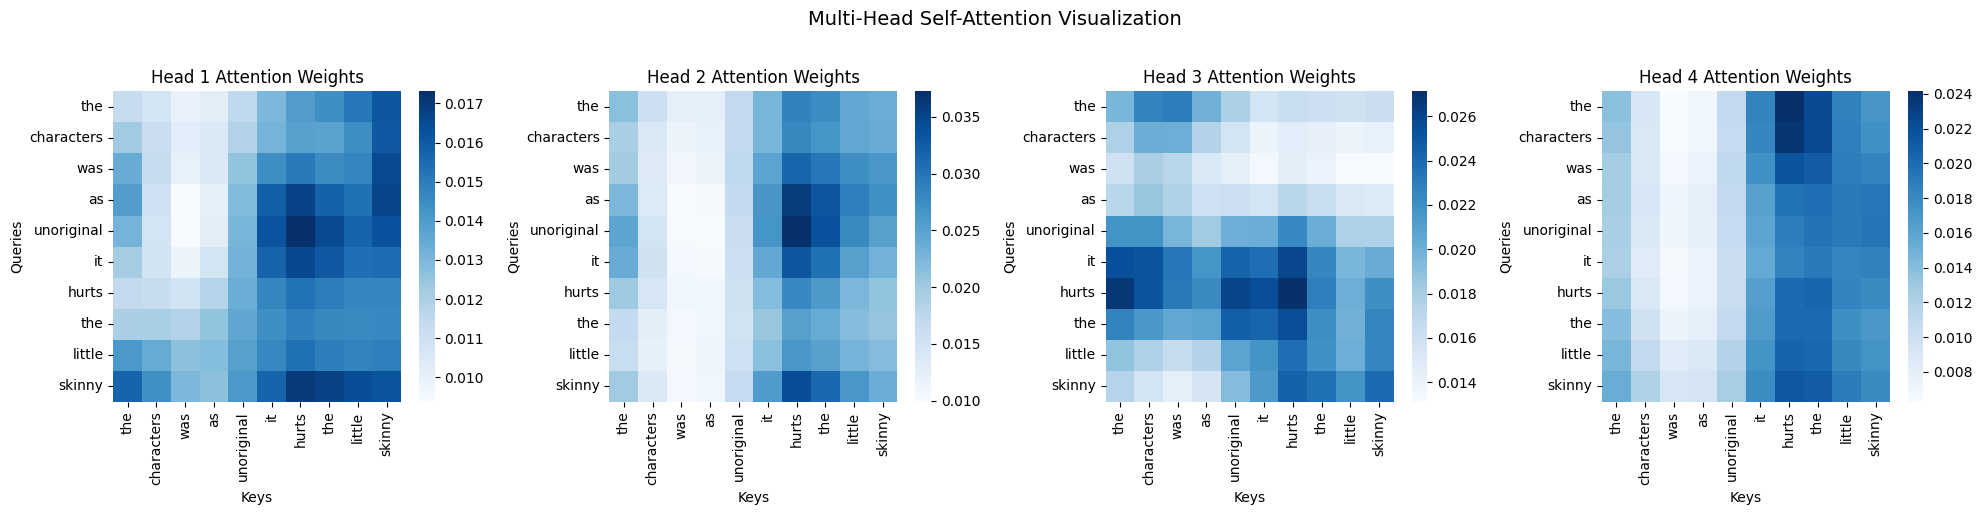

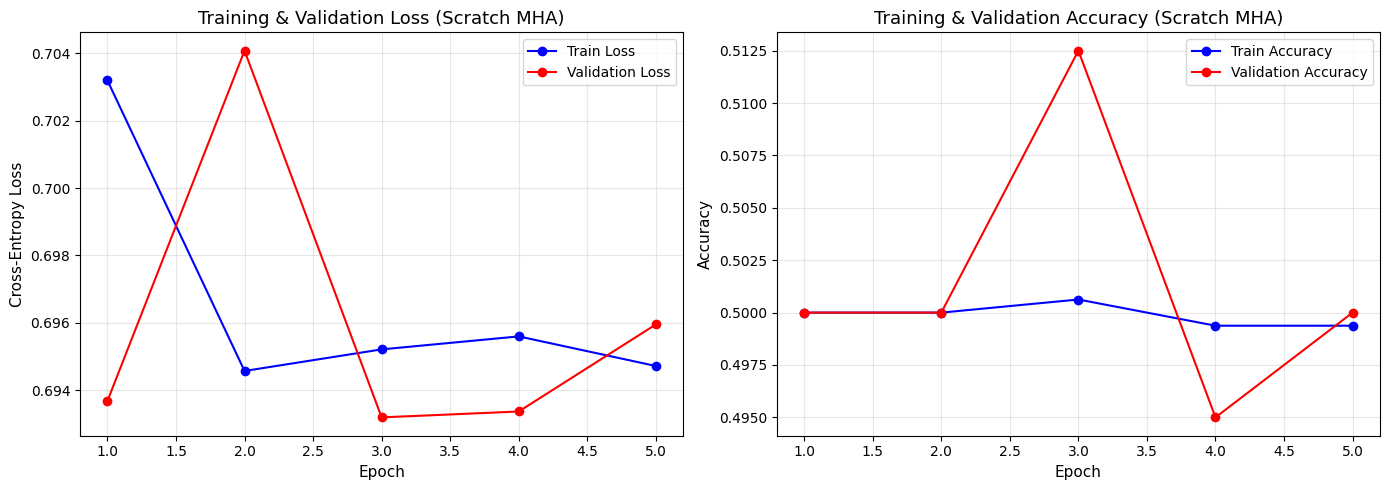

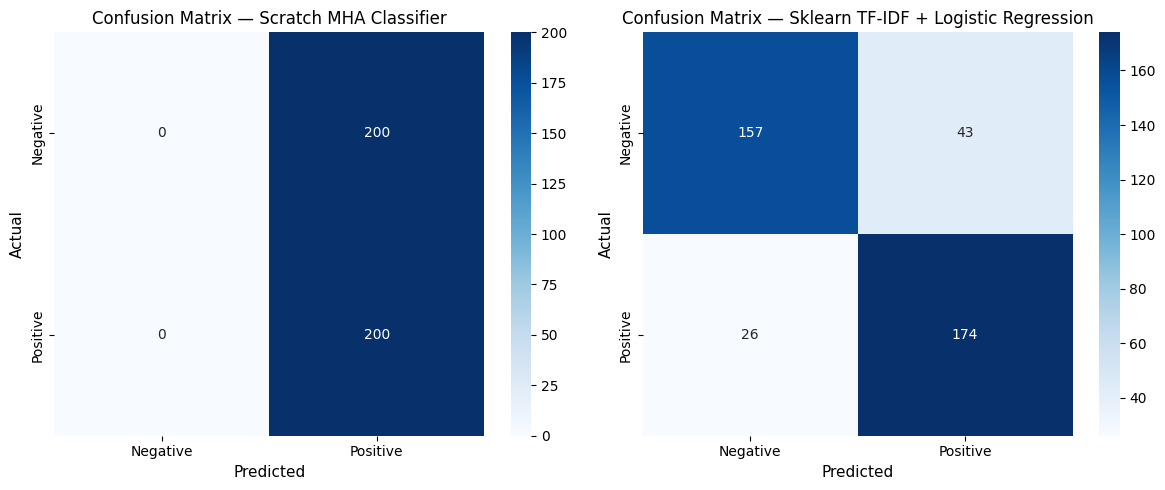

In [7]:
# ============================================================
# VISUALIZATION 1: Attention Weight Heatmap
# ============================================================
# Extract attention weights from the scratch model on a test sample
sample_idx = 0
sample_text = reviews_test.iloc[sample_idx]
sample_tokens = tokenize(sample_text)[:MAX_LEN]
sample_encoded = X_test[sample_idx:sample_idx+1]

mask = scratch_model._get_attention_mask(sample_encoded)
_, attn_weights = scratch_model.forward(sample_encoded, mask)
# attn_weights shape: (1, num_heads, seq_len, seq_len) — take first batch
attn_weights = attn_weights[0]  # (num_heads, seq_len, seq_len)

# Only show non-padding tokens
seq_len_actual = len(sample_tokens)

fig, axes = plt.subplots(1, NUM_HEADS, figsize=(5 * NUM_HEADS, 5))
if NUM_HEADS == 1:
    axes = [axes]
for head_idx in range(NUM_HEADS):
    ax = axes[head_idx]
    vis_len = min(seq_len_actual, 10)
    heatmap = attn_weights[head_idx, :vis_len, :vis_len]
    sns.heatmap(heatmap, ax=ax, cmap='Blues', cbar=True,
                xticklabels=sample_tokens[:vis_len], yticklabels=sample_tokens[:vis_len])
    ax.set_title(f'Head {head_idx + 1} Attention Weights', fontsize=12)
    ax.set_xlabel('Keys', fontsize=10)
    ax.set_ylabel('Queries', fontsize=10)
plt.suptitle('Multi-Head Self-Attention Visualization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2: Training Curves & Metric Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curves
ax = axes[0]
ax.plot(range(1, EPOCHS + 1), history['train_loss'], 'b-o', label='Train Loss')
ax.plot(range(1, EPOCHS + 1), history['val_loss'], 'r-o', label='Validation Loss')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.set_title('Training & Validation Loss (Scratch MHA)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Accuracy curves
ax = axes[1]
ax.plot(range(1, EPOCHS + 1), history['train_acc'], 'b-o', label='Train Accuracy')
ax.plot(range(1, EPOCHS + 1), history['val_acc'], 'r-o', label='Validation Accuracy')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Training & Validation Accuracy (Scratch MHA)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 3: Confusion Matrices Comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_scratch, y_pred_sklearn],
                              ['Scratch MHA Classifier', 'Sklearn TF-IDF + Logistic Regression']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)

plt.tight_layout()
plt.show()

## Part 4: Hyperparameter Experiments

The two most critical hyperparameters in Multi-Head Attention are:
1. **Number of heads (`num_heads`):** Controls how many independent attention subspaces the model uses. Too few heads limits representational power; too many heads may split the model dimension too thin (`d_k` becomes very small), reducing each head's capacity.
2. **Model dimension (`d_model`):** The dimensionality of the embedding and attention output. Higher `d_model` increases capacity but also quadratically increases parameter count (both in projection matrices and attention computation).

We vary `num_heads` and `d_model` and measure their effect on validation accuracy.

HYPERPARAMETER EXPERIMENT 1: Varying Number of Heads
Heads:  1 | d_k: 64 | Val Acc: 0.5000
Heads:  2 | d_k: 32 | Val Acc: 0.4900
Heads:  4 | d_k: 16 | Val Acc: 0.5125

HYPERPARAMETER EXPERIMENT 2: Varying Model Dimension (d_model)
d_model:  16 | Heads: 4 | Val Acc: 0.5150
d_model:  32 | Heads: 4 | Val Acc: 0.5175
d_model:  64 | Heads: 4 | Val Acc: 0.5125


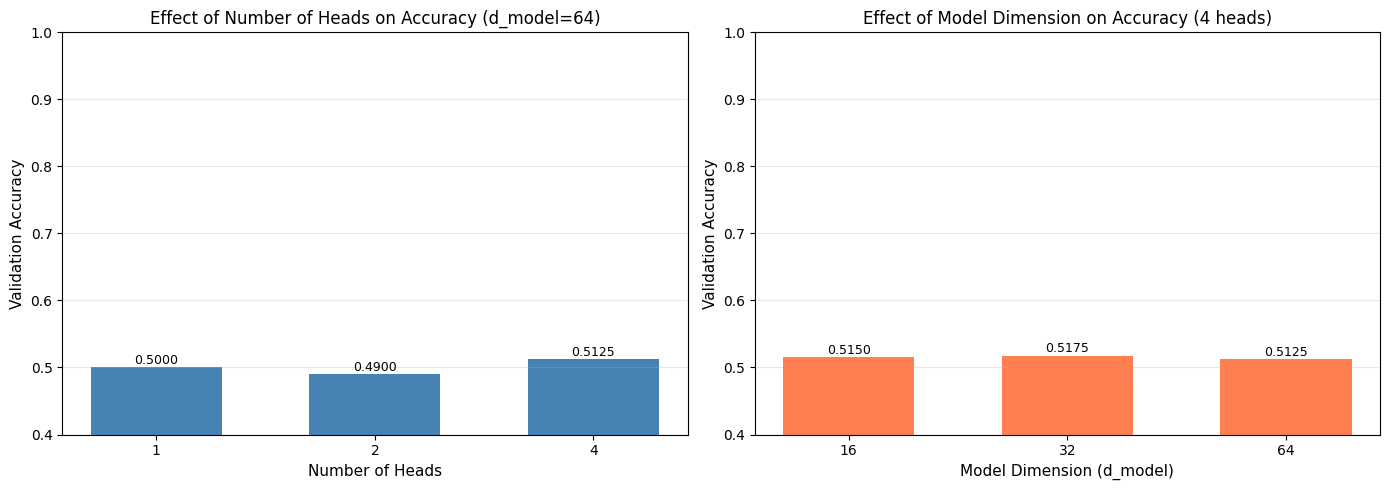


Key observation: More heads generally improves performance up to a point,
but if d_k becomes too small, each head lacks capacity.
d_model controls total capacity — larger models fit better but need more data.


In [8]:
# --- Experiment 1: Vary number of heads ---
print("=" * 60)
print("HYPERPARAMETER EXPERIMENT 1: Varying Number of Heads")
print("=" * 60)

head_values = [1, 2, 4]
head_results = []

for h in head_values:
    # Ensure d_model is divisible by h (use 64, which is divisible by 1, 2, 4, 8)
    model = AttentionClassifier(
        vocab_size=len(vocab), d_model=64, num_heads=h,
        max_len=MAX_LEN, num_classes=2
    )
    # Train for fewer epochs for speed
    hist = model.fit(X_train, y_train, X_test, y_test,
                     epochs=3, batch_size=32, lr=0.005, verbose=False)
    val_acc = hist['val_acc'][-1]
    head_results.append({'num_heads': h, 'val_acc': val_acc,
                         'd_k': 64 // h})
    print(f"Heads: {h:2d} | d_k: {64//h:2d} | Val Acc: {val_acc:.4f}")

# --- Experiment 2: Vary model dimension ---
print("\n" + "=" * 60)
print("HYPERPARAMETER EXPERIMENT 2: Varying Model Dimension (d_model)")
print("=" * 60)

d_model_values = [16, 32, 64]
d_model_results = []

for d in d_model_values:
    # Keep 4 heads (or adjust if d is too small)
    h = min(4, d // 4)
    if h == 0:
        h = 1
    # Ensure divisibility
    while d % h != 0:
        h -= 1

    model = AttentionClassifier(
        vocab_size=len(vocab), d_model=d, num_heads=h,
        max_len=MAX_LEN, num_classes=2
    )
    hist = model.fit(X_train, y_train, X_test, y_test,
                     epochs=3, batch_size=32, lr=0.005, verbose=False)
    val_acc = hist['val_acc'][-1]
    d_model_results.append({'d_model': d, 'num_heads': h, 'val_acc': val_acc,
                            'params': 4 * d * d + len(vocab) * d + d * 2})
    print(f"d_model: {d:3d} | Heads: {h} | Val Acc: {val_acc:.4f}")

# --- Plot results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Effect of number of heads
ax = axes[0]
head_df = pd.DataFrame(head_results)
ax.bar(head_df['num_heads'].astype(str), head_df['val_acc'], color='steelblue', width=0.6)
ax.set_xlabel('Number of Heads', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Effect of Number of Heads on Accuracy (d_model=64)', fontsize=12)
for i, v in enumerate(head_df['val_acc']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
ax.set_ylim(0.4, 1.0)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Effect of d_model
ax = axes[1]
dm_df = pd.DataFrame(d_model_results)
ax.bar(dm_df['d_model'].astype(str), dm_df['val_acc'], color='coral', width=0.6)
ax.set_xlabel('Model Dimension (d_model)', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Effect of Model Dimension on Accuracy (4 heads)', fontsize=12)
for i, v in enumerate(dm_df['val_acc']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
ax.set_ylim(0.4, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observation: More heads generally improves performance up to a point,")
print("but if d_k becomes too small, each head lacks capacity.")
print("d_model controls total capacity — larger models fit better but need more data.")

## Part 5: Interview Corner

### "Explain the scaled dot-product attention formula and why the scaling factor matters."

**Formula:** `Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V`

Here's how to reason through it step by step:

1. **What Q, K, V represent.** In self-attention, every token produces a Query (what am I looking for?), a Key (what do I contain?), and a Value (what information do I carry?). The dot product `Q @ K^T` measures similarity between every pair of tokens — if a token's query matches another token's key, they get a high score.

2. **Why scale by `1/sqrt(d_k)`.** The dot products of two `d_k`-dimensional vectors have variance `d_k` (assuming unit variance inputs). As `d_k` grows, the dot products get larger, pushing the softmax into regions with very small gradients — the model stops learning. Dividing by `sqrt(d_k)` normalizes the variance back to ~1, keeping gradients healthy.

3. **Why softmax?** The softmax converts raw similarity scores into a probability distribution over the sequence — each token now decides "what fraction of my attention goes to each other token." The sum-to-1 property ensures the output is a convex combination of values, keeping magnitudes bounded.

4. **Why multiple heads?** With a single head, every token gets one attention distribution. With `h` heads, each token gets `h` independent distributions, each operating in a smaller subspace (`d_k = d_model / h`). Empirically, different heads learn different patterns — e.g., one head might focus on syntactic dependencies while another captures semantic similarity. The concatenated output lets the model express complex relationships no single distribution can capture.

**In an interview, also mention:** The time complexity is `O(n^2 * d_k)` per head (where `n` = sequence length) due to the `Q @ K^T` matrix multiply. This quadratic scaling is why long-document Transformers use sparse or linear attention variants.

## Key Takeaways

- **Multi-Head Attention computes `softmax(Q K^T / sqrt(d_k)) V` in `h` parallel subspaces** — each head projects Q, K, V into a lower dimension, attends independently, and the results are concatenated and re-projected. This lets the model capture diverse relationships simultaneously.
- **The `sqrt(d_k)` scaling factor is not optional** — without it, dot products grow with dimension, softmax gradients vanish, and training fails. Always mention this as a critical stability mechanism.
- **Self-attention is permutation-invariant** — it has no built-in notion of token order. Positional encodings (sinusoidal or learned) must be added to the input embeddings to inject sequence structure.
- **Quadratic complexity `O(n^2 d)` per layer** is the main practical bottleneck. For long sequences, this dominates compute cost. Variants like Linformer, Performer, and FlashAttention address this.
- **TF-IDF + LogisticRegression is a strong, fast baseline** — it often matches or exceeds simple attention models on short-text classification because it captures word-level salience efficiently. Attention shines when long-range dependencies or complex interactions matter.